
--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una opción: 1

ID	Producto	Precio	Stock
101	Cuaderno    	$15.5	50
102	Mochila     	$25.0	30
103	Bolígrafo   	$10.0	100
104	Calculadora 	$50.0	20
105	Borrador    	$5.25	200
--- Operación finalizada ---

--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una opción: 2
Ingrese ID del producto a vender: 7
 Error: El producto 7 no existe en el catálogo.
--- Operación finalizada ---

--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una op

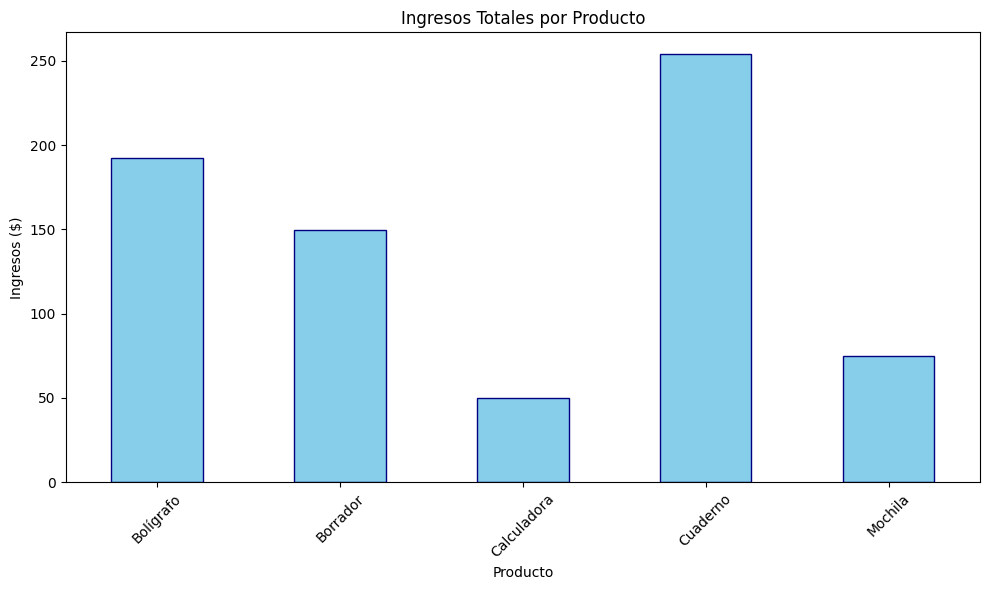

--- Operación finalizada ---

--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una opción: 6
 Gráfico exportado como 'ingresos.png'


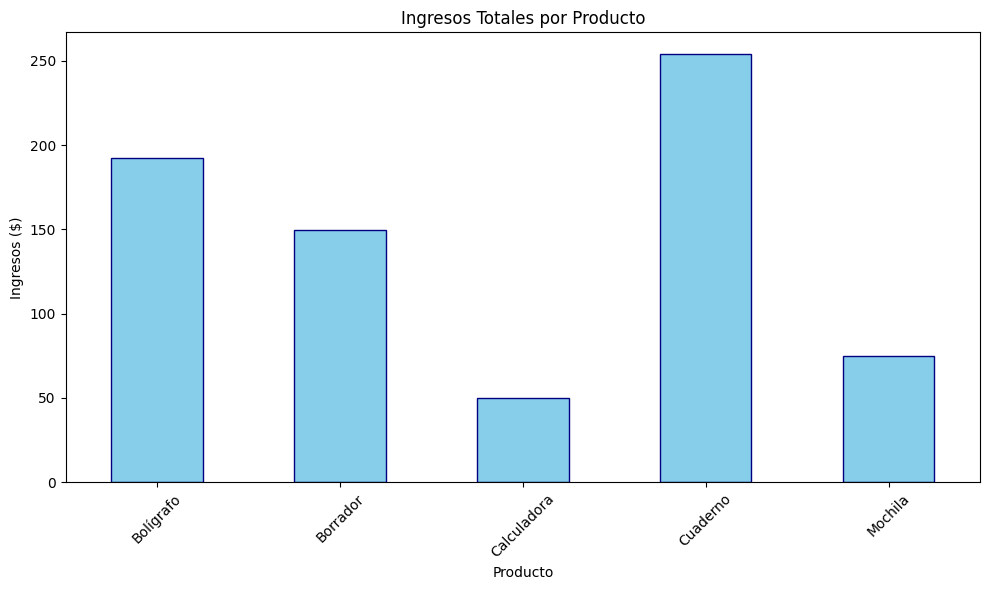

--- Operación finalizada ---

--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una opción: silla
 Opción no válida.
--- Operación finalizada ---

--- SISTEMA DE GESTIÓN DE VENTAS ---
1) Ver Catálogo y Stock
2) Registrar Venta
3) Ver Métricas (NumPy)
4) Ver Gráfico de Ingresos
5) Agregar Nuevo Producto (Reto A)
6) Exportar Gráfico a PNG (Reto B)
7) Salir
Seleccione una opción: 7
Saliendo del sistema...
--- Operación finalizada ---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime

# --- CONFIGURACIÓN INICIAL ---
# Tupla: Catálogo de IDs (Inmutable)
catalogo = (101, 102, 103, 104, 105)

# Diccionarios: Precios y Stock
precios = {101: 15.50, 102: 25.00, 103: 10.00, 104: 50.00, 105: 5.25}
stock = {101: 50, 102: 30, 103: 100, 104: 20, 105: 200}
nombres = {101: "Cuaderno", 102: "Mochila", 103: "Bolígrafo", 104: "Calculadora", 105: "Borrador"}

ARCHIVO_CSV = "ventas.csv"
ARCHIVO_LOG = "log.txt"

def registrar_error(mensaje):
    """Reto D: Escribe errores en log.txt"""
    with open(ARCHIVO_LOG, "a") as f:
        fecha = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{fecha}] ERROR: {mensaje}\n")

def inicializar_csv():
    """Genera un CSV inicial si no existe con 10 ventas de ejemplo"""
    if not os.path.exists(ARCHIVO_CSV):
        data = {
            'id_producto': [101, 102, 101, 103, 105, 104, 102, 101, 103, 105],
            'cantidad': [2, 1, 12, 5, 20, 1, 2, 3, 15, 10],
            'total': [31.0, 25.0, 176.7, 50.0, 99.75, 50.0, 50.0, 46.5, 142.5, 49.88]
        }
        df = pd.DataFrame(data)
        df.to_csv(ARCHIVO_CSV, index=False)
        print("✔ Archivo ventas.csv creado con datos iniciales.")

def agregar_producto():
    """Reto A: Agrega un producto nuevo al catálogo y actualiza diccionarios"""
    global catalogo
    try:
        nuevo_id = int(input("Ingrese nuevo ID de producto: "))
        if nuevo_id in catalogo:
            print(" El ID ya existe.")
            return

        nombre = input("Nombre del producto: ")
        precio = float(input("Precio: "))
        cantidad = int(input("Stock inicial: "))

        # Actualizar Estructuras
        catalogo += (nuevo_id,) # Reto A: Extender tupla
        nombres[nuevo_id] = nombre
        precios[nuevo_id] = precio
        stock[nuevo_id] = cantidad
        print(f"Producto '{nombre}' agregado exitosamente.")
    except ValueError:
        print(" Error: Ingrese valores numéricos válidos.")

def realizar_venta():
    """Registra una venta con validaciones y Retos C y D"""
    try:
        pid = int(input("Ingrese ID del producto a vender: "))

        # Reto D: Validar existencia y registrar error en log
        if pid not in catalogo:
            msg = f"Intento de venta de producto inexistente ID: {pid}"
            registrar_error(msg)
            print(f" Error: El producto {pid} no existe en el catálogo.")
            return

        cant = int(input(f"Cantidad de '{nombres[pid]}' (Stock: {stock[pid]}): "))

        if cant <= 0:
            print(" La cantidad debe ser mayor a 0.")
            return
        if cant > stock[pid]:
            print(" Stock insuficiente.")
            return

        # Cálculo de precio
        precio_unitario = precios[pid]
        total = precio_unitario * cant

        # Reto C: Descuento del 5% si lleva 10 o más unidades
        if cant >= 10:
            descuento = total * 0.05
            total -= descuento
            print(f" ¡Descuento del 5% aplicado! Ahorraste: ${descuento:.2f}")

        # Actualizar Stock
        stock[pid] -= cant

        # Guardar en CSV usando Pandas
        nueva_venta = pd.DataFrame([[pid, cant, total]], columns=['id_producto', 'cantidad', 'total'])
        nueva_venta.to_csv(ARCHIVO_CSV, mode='a', header=False, index=False)

        print(f" Venta registrada. Total: ${total:.2f}")

    except ValueError:
        print(" Error: Entrada inválida. Ingrese números enteros.")

def mostrar_metricas():
    """Uso de NumPy para estadísticas"""
    try:
        df = pd.read_csv(ARCHIVO_CSV)
        if df.empty:
            print("No hay datos para calcular.")
            return

        totales = df['total'].to_numpy() # Convertir a arreglo NumPy

        print("\n--- MÉTRICAS DE VENTAS (NumPy) ---")
        print(f"Suma Total Ingresos:  ${np.sum(totales):.2f}")
        print(f"Promedio por Venta:   ${np.mean(totales):.2f}")
        print(f"Desviación Estándar:  ${np.std(totales):.2f}")
        print(f"Venta Máxima:         ${np.max(totales):.2f}")

    except FileNotFoundError:
        print(" Error: No existe el archivo de ventas.")
    except ZeroDivisionError:
        print(" Error: No se puede calcular el promedio de cero ventas.")

def graficar_ingresos(exportar=False):
    """Reto B: Graficar y opcionalmente exportar a PNG"""
    try:
        df = pd.read_csv(ARCHIVO_CSV)
        # Agrupar por nombre usando el diccionario nombres
        df['nombre_prod'] = df['id_producto'].map(nombres)
        reporte = df.groupby('nombre_prod')['total'].sum()

        plt.figure(figsize=(10, 6))
        reporte.plot(kind='bar', color='skyblue', edgecolor='navy')
        plt.title("Ingresos Totales por Producto")
        plt.xlabel("Producto")
        plt.ylabel("Ingresos ($)")
        plt.xticks(rotation=45)
        plt.tight_layout()

        if exportar:
            plt.savefig("ingresos.png")
            print(" Gráfico exportado como 'ingresos.png'")

        plt.show()
    except Exception as e:
        print(f" Error al graficar: {e}")

# --- BUCLE PRINCIPAL (MENÚ) ---
def menu():
    inicializar_csv()
    while True:
        print("\n--- SISTEMA DE GESTIÓN DE VENTAS ---")
        print("1) Ver Catálogo y Stock")
        print("2) Registrar Venta")
        print("3) Ver Métricas (NumPy)")
        print("4) Ver Gráfico de Ingresos")
        print("5) Agregar Nuevo Producto (Reto A)")
        print("6) Exportar Gráfico a PNG (Reto B)")
        print("7) Salir")

        opcion = input("Seleccione una opción: ")

        try:
            if opcion == "1":
                print("\nID\tProducto\tPrecio\tStock")
                for pid in catalogo:
                    print(f"{pid}\t{nombres[pid]:<12}\t${precios[pid]}\t{stock[pid]}")
            elif opcion == "2":
                realizar_venta()
            elif opcion == "3":
                mostrar_metricas()
            elif opcion == "4":
                graficar_ingresos(exportar=False)
            elif opcion == "5":
                agregar_producto()
            elif opcion == "6":
                graficar_ingresos(exportar=True)
            elif opcion == "7":
                print("Saliendo del sistema...")
                break
            else:
                print(" Opción no válida.")
                continue
        except Exception as e:
            print(f"Ocurrió un error inesperado: {e}")
        finally:
            print("--- Operación finalizada ---")

if __name__ == "__main__":
    menu()